# Report of movie recommender project

## Introduction

This project intends to produce a movie-recommendation modell based on tags and ratings using a large dataset.
The modell makes use of k-nearest neighbor and tf-idf Vectorization to compute relevant recommendations.

## Data Analysis

The dataset was composed from three csv-files, and processed to contain the features "title", "cleaned_title", "rating", "movieId", "userId" and "tags".
The "genre" feature and the "tag" feature were merged to create a "tags" feature, so as to minimize the tf-idf computation.
Duplicates were joined. Nan-values were removed. And A feature engineering function was created to identify and remove the ratings of suspect userIds.
The feature engineering included a tfidf-matrix. For this the cleaned dataframe (aproximately 35.000.000 rows long) was redundant. Instead the dataframe movie_df (aproximately 86.000 rows long). Much more efficient for the tf-idf-matrix generation.
The tf-idf-matrix was then used in a nearest neighbor model

## Modell

The tf-idf-matrix, the nearest neighbor model and the indices list of the 50 nearest neigbors were used in the recommender model to firstly get 50 recommendations based on the knn results. Secondly the ratings of these 50 recommendations were applied to return two list of 5 recommendations each. The first list produced the highest ranked recommendations. The second list produced the most similarily ranked recommendations to the target movie. A third function was added to the recommender to produce a ranking for the target movie to be used in the visualization for easy comparison to the recomendations.
To vizualize the results a dash application was created.

## Results

Highly rated target movie

"Inception (2010)" - rating: 4.2

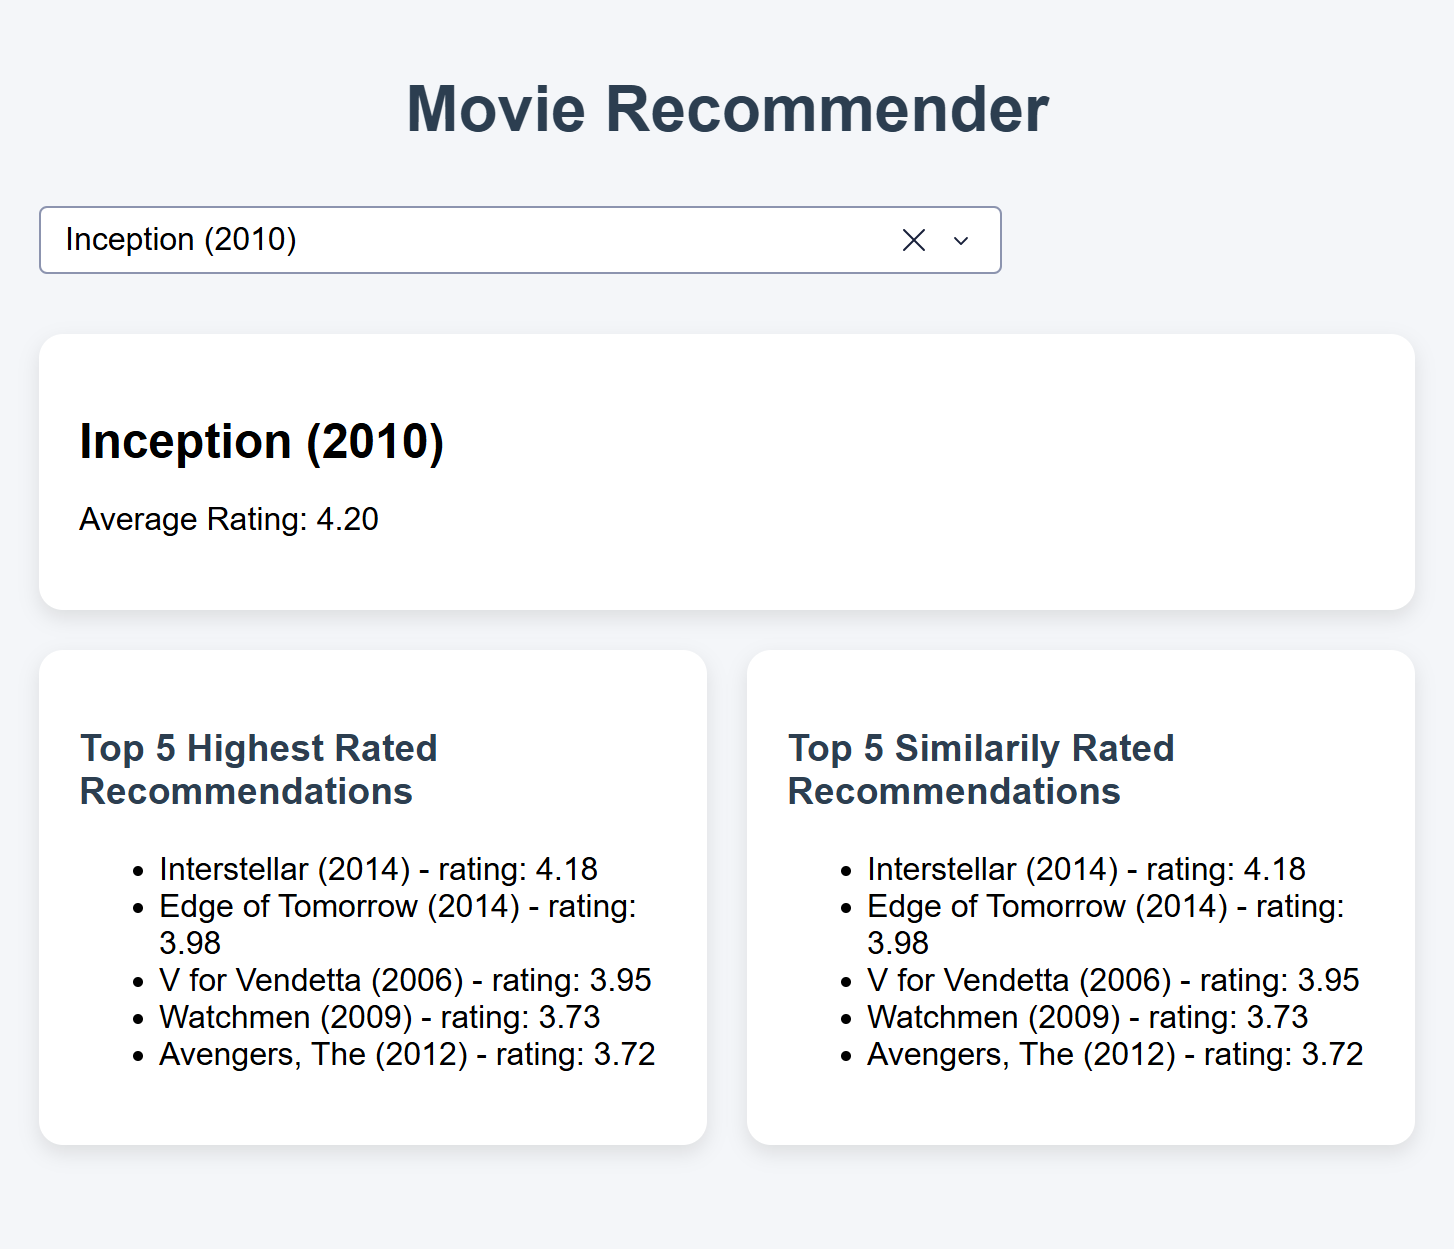

Highly rated cult following target movie

"Lock, Stock & Two Smoking Barrels (1998)" - 4.04

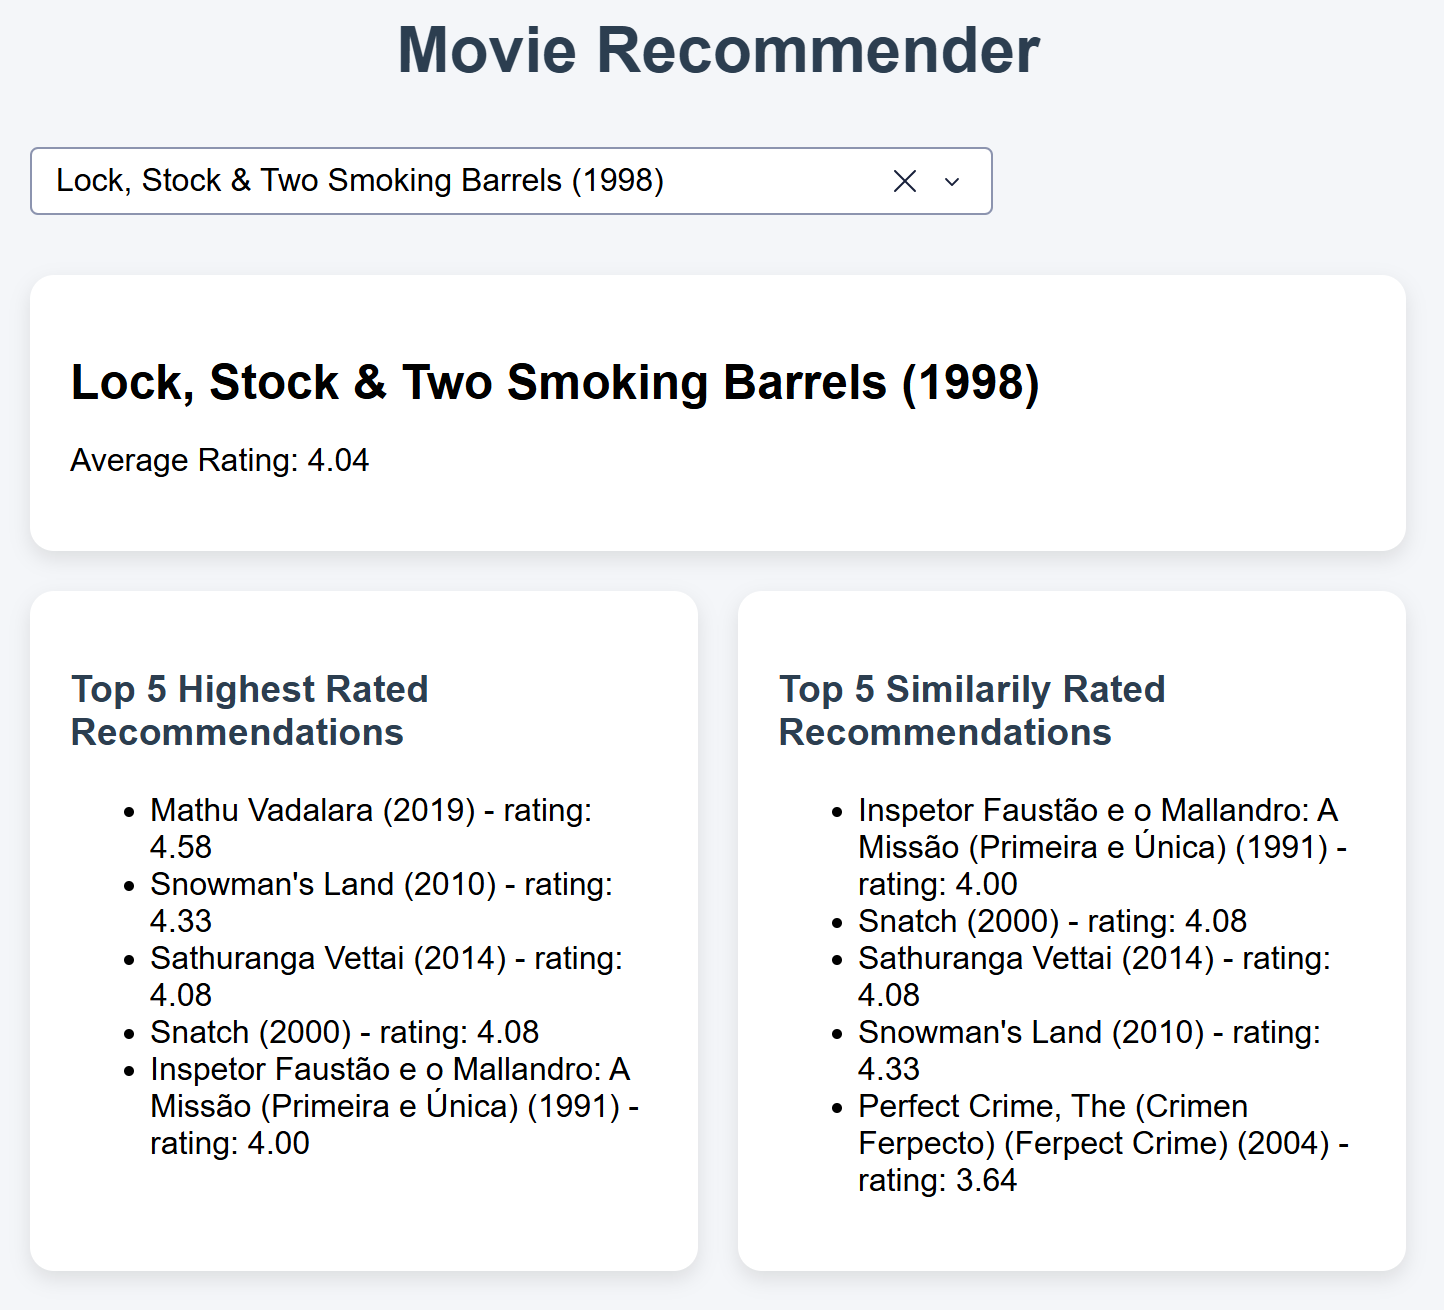

Low rated childrens movie target movie

"Pocahontas (1995)" rating 2.98

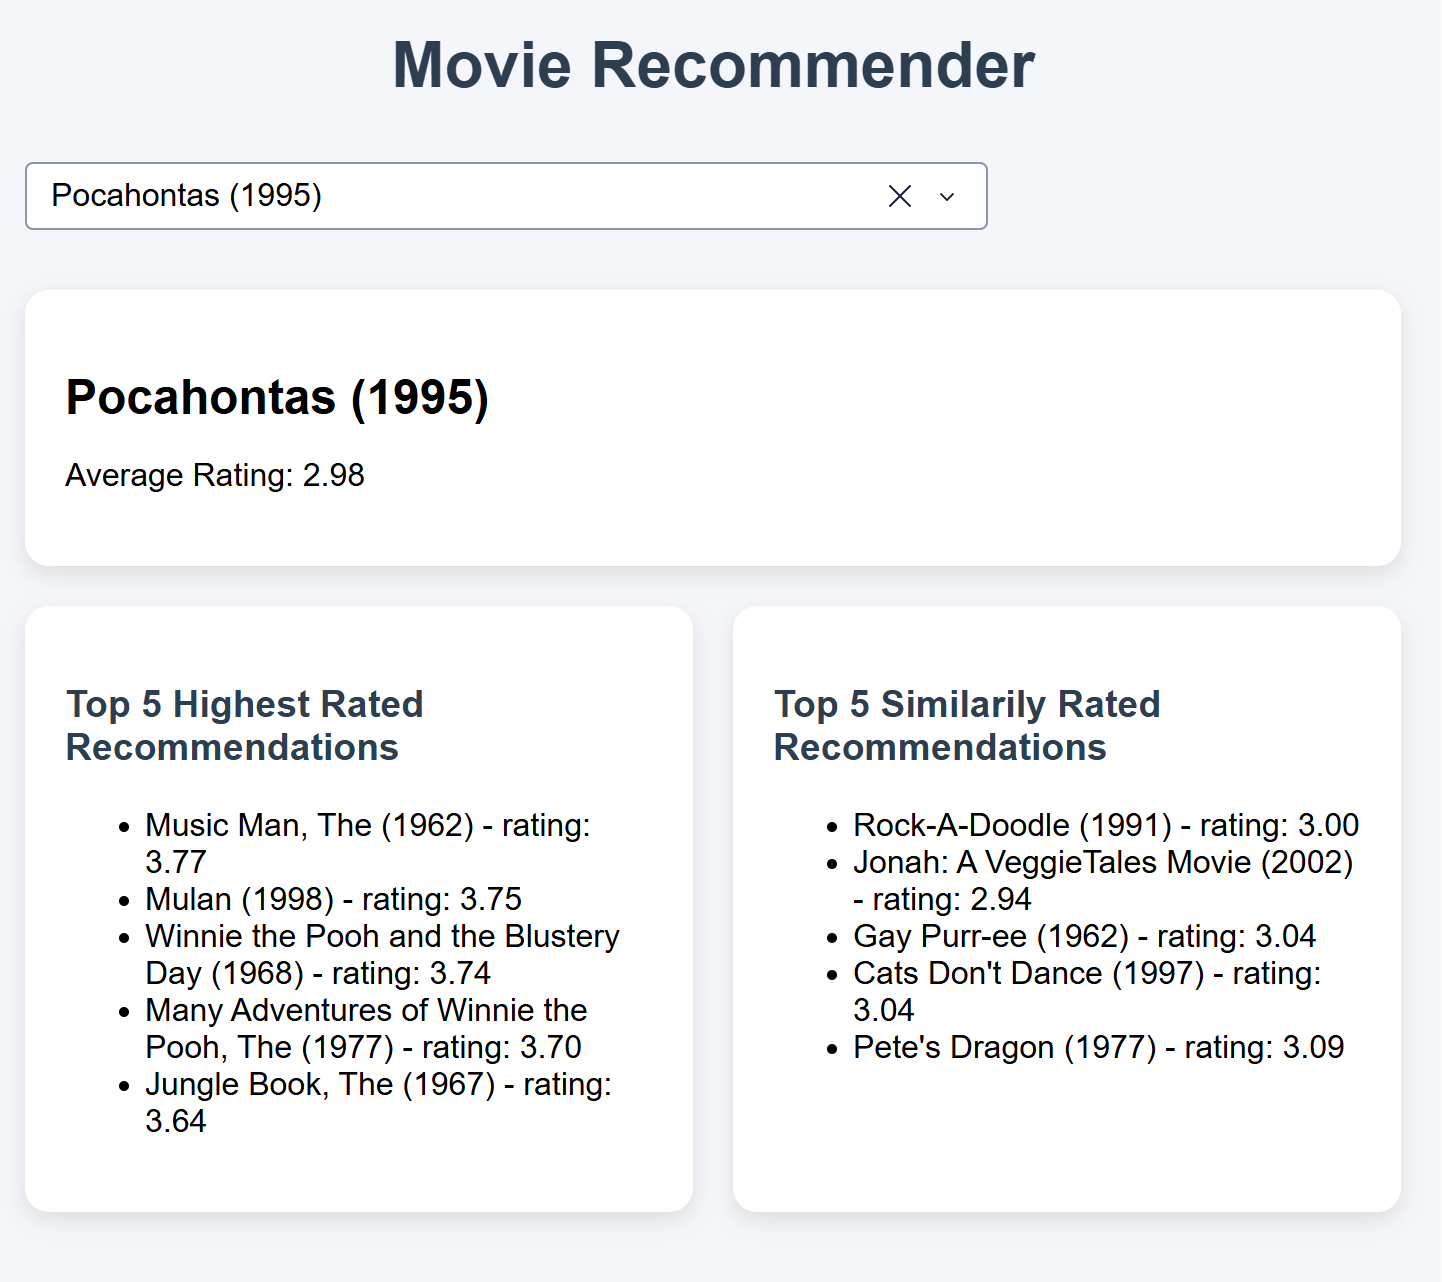

## Discussion

The three different example target movies were chosen due to their rating and subsequent reflection of the models capasities and inadequies.

The first example, "Inception", a high rated movie. The model produced relevant recommendations but due to the movies high rating, the "Similarily rated" category was not necesary.

The second example, "Lock, Stock & Two Smoking Barrels", a high reted movie with a more cult following. The model produced a wider range of movies. The renowned director of the target movie led to the assumption that the result would contain at least one other movie directed by the same man. The assumption was proven correct. The other recommendations however held a wide range in both language and rating. The "Similarily rated" category once again was unnecesary.

The third example, "Pocahontas", a childrens movie without a cult following. The movie was expected to hold a below average rating and assumed to produce a variety of recommendations. For this target movie the two different reccomendations lists proved useful. The dataset seems to have the majority of movies be rated around 3.0. 

 

An examination of ratings given by specific UserID led to the filtering of "suspect" ratings. Where a UserID would rate movies contradictingly to what the general rating would be. As such the number of ratings was reduced, pressumed resulting in easier processing, and the content of the ratings to be more accurate.
However, an improvement of the datafiltering would be to question the similarity of a userId and the user which is recieving a recommendation. A user could for example enjoy foreign films with subtitles, whereas a userId might only enjoy american action movies. More features in the testdata would prove effective for a more accurate feature engineering.

In [30]:
from data_processing import get_df
from feature_engineering import filter_out_suspect_users

In [45]:
df = get_df()
cleaned_df, mean_ratings = filter_out_suspect_users(df)

In [42]:
df.shape, cleaned_df.shape

((35224048, 6), (35216331, 6))

The "suspect userId" function resulted in the removal of 7717 rows.

For a dataframe with 35M rows, the function did not affect the result the way it was intended. For this function to hold value, the dataframe would need more features so as to be more discriminate.

In [43]:
df["movieId"].nunique(), cleaned_df["movieId"].nunique()

(83040, 82887)

The suspect userId function had the negative effect of removing 153 unique movieIds from the dataset. Thus removing potential recommendations.
The discriminate function would do well with a clause hindering the elimination of a movie from the dataset.

In [46]:
df.memory_usage(deep=True).sort_values(ascending=False)/ 1024**2

title            2513.640420
tags             2352.062736
cleaned_title    2254.089100
movieId           268.738159
userId            268.738159
Index             268.738159
rating            268.738159
dtype: float64

The dataframes use up a large amount of memory, which is why the tags column was removed after tfidf_matrix computation. Relieving some of the pressure, but not as much as desired. For optimal usage of the model, there would need to be modifications made to the code.

ChatGPT användes för att skapa en mall till dash app layout. Se Källa i dash_vis.py